# 02 -- Feature engineering

Мы решаем регрессию задержки ТС на целевом приезде через 10--15 минут.

В этом ноутбуке я строю признаки для `train`, `test` и `validate` одной логикой. Использую только информацию, которая доступна к моменту `T`.

### Что беру из EDA

- `cur_dev_s` -- главный одиночный сигнал, но сам по себе дает слабый baseline;
- важна не одна скорость, а динамика движения перед `T`;
- у возраста телеметрии, lag, расстояний и части GPS-полей тяжелые хвосты;
- `location_valid=False` связано с отдельным режимом качества данных;
- время суток влияет на target;
- train в основном синтетический, поэтому признаки должны переноситься на реальные ТС.

Для ETA/delay prediction обычно используют schedule adherence, headway, историю GPS, скорость, расстояние и прогресс по маршруту, локальный транспортный контекст и multi-resolution пространственно-временные агрегаты. Эти же группы признаков строю здесь.
- PCA показывает распределенную структуру: 2--3 компонент недостаточно;
- RF подтверждает важность `cur_dev_s`, но также выделяет географию, время суток и расстояние до target -- добавляю их взаимодействия, а не только сырые значения.


## 1. Загрузка


In [93]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [94]:
FE_SEED = 143
FE_WINDOWS = (1, 3, 5, 10, 15, 30)
FE_RADII = (300, 500, 1000, 2000)

FE_SPEED_CAP = 120
FE_ALT_MIN = 0
FE_ALT_MAX = 1000

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

In [95]:
fe_traffic_dates = ['event_time', 'gps_time', 'receive_time']
fe_schedule_dates = ['time_begin', 'order_date']
fe_point_dates = ['T', 'target_time_begin']

fe_schedule_cols = [
    'tt_action_item_id', 'time_begin', 'order_date', 'manual_fill',
    'tr_id', 'geom', 'building_address'
]


In [96]:
fe_train_traffic = pd.read_csv(
    '../dataset/train/traffic.csv',
    dtype={'packet_id': 'string'},
    parse_dates=fe_traffic_dates
)
fe_test_traffic = pd.read_csv(
    '../dataset/test/traffic.csv',
    dtype={'packet_id': 'string'},
    parse_dates=fe_traffic_dates
)
fe_validate_traffic = pd.read_csv(
    '../dataset/validate/traffic.csv',
    dtype={'packet_id': 'string'},
    parse_dates=fe_traffic_dates
)

fe_train_schedule = pd.read_csv(
    '../dataset/train/schedule.csv',
    usecols=fe_schedule_cols,
    parse_dates=fe_schedule_dates
)
fe_test_schedule = pd.read_csv(
    '../dataset/test/schedule.csv',
    usecols=fe_schedule_cols,
    parse_dates=fe_schedule_dates
)
fe_validate_schedule = pd.read_csv(
    '../dataset/validate/schedule_plan.csv',
    parse_dates=fe_schedule_dates
)

fe_train_points = pd.read_csv('../dataset/labels/labels_train.csv', parse_dates=fe_point_dates)
fe_test_points = pd.read_csv('../dataset/labels/labels_test.csv', parse_dates=fe_point_dates)
fe_validate_points = pd.read_csv('../dataset/validate/points.csv', parse_dates=fe_point_dates)


`time_fact_begin` намеренно отсутствует уже на этапе чтения `train_schedule` и `test_schedule`. Так ниже невозможно случайно протащить факт прибытия в признаки.

`test` оставляю отдельным real holdout. `validate` использую только для финального инференса.


In [97]:
pd.DataFrame({
    'traffic': [len(fe_train_traffic), len(fe_test_traffic), len(fe_validate_traffic)],
    'schedule': [len(fe_train_schedule), len(fe_test_schedule), len(fe_validate_schedule)],
    'points': [len(fe_train_points), len(fe_test_points), len(fe_validate_points)],
}, index=['train', 'test', 'validate'])


,traffic,schedule,points
train,287849,16674,4434
test,105945,5558,353
validate,105945,5558,151


## 2. Геометрия и базовая очистка


In [98]:
def fe_haversine_m(lon1, lat1, lon2, lat2):
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6_371_000 * np.arcsin(np.sqrt(a))


In [99]:
def fe_bearing_deg(lon1, lat1, lon2, lat2):
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)

    return (np.degrees(np.arctan2(x, y)) + 360) % 360


In [100]:
def fe_angle_diff_deg(a, b):
    return ((a - b + 180) % 360) - 180


In [101]:
def fe_signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


In [102]:
def fe_prepare_traffic(df):
    x = df.copy()

    for col in ['event_time', 'gps_time', 'receive_time']:
        x[col] = x[col].astype('datetime64[ns]')

    x['available_time'] = x[['event_time', 'receive_time']].max(axis=1).astype('datetime64[ns]')
    x['receive_lag_s'] = (x.receive_time - x.event_time).dt.total_seconds()
    x['gps_event_lag_s'] = (x.event_time - x.gps_time).dt.total_seconds()

    x['speed_outlier'] = x.speed > FE_SPEED_CAP
    x['alt_outlier'] = (x.alt < FE_ALT_MIN) | (x.alt > FE_ALT_MAX)

    x['speed_clean'] = x.speed.clip(0, FE_SPEED_CAP)
    x['alt_clean'] = x.alt.clip(FE_ALT_MIN, FE_ALT_MAX)
    x['valid_coords'] = x.location_valid & x.lon.notna() & x.lat.notna()

    return x.sort_values(['tr_id', 'available_time']).reset_index(drop=True)

In [103]:
def fe_prepare_schedule(df):
    x = df.copy()
    x['time_begin'] = x.time_begin.astype('datetime64[ns]')

    coords = x.geom.str.extract(r'POINT \(([-\d.]+) ([-\d.]+)\)').astype(float)
    x['stop_lon'] = coords[0]
    x['stop_lat'] = coords[1]

    x['stop_key'] = (
        x.stop_lon.round(5).astype('string')
        + '_'
        + x.stop_lat.round(5).astype('string')
    )
    x['address_missing'] = x.building_address.isna().astype('int8')

    x = x.sort_values(['tr_id', 'time_begin']).reset_index(drop=True)
    by_vehicle = x.groupby('tr_id', sort=False)

    x['schedule_pos'] = by_vehicle.cumcount()
    x['schedule_rows'] = by_vehicle.tr_id.transform('size')
    x['schedule_progress'] = x.schedule_pos / (x.schedule_rows - 1).replace(0, np.nan)

    x['planned_gap_prev_s'] = by_vehicle.time_begin.diff().dt.total_seconds()
    x['planned_gap_next_s'] = (
        by_vehicle.time_begin.shift(-1) - x.time_begin
    ).dt.total_seconds()

    x['prev_stop_lon'] = by_vehicle.stop_lon.shift(1)
    x['prev_stop_lat'] = by_vehicle.stop_lat.shift(1)
    x['next_stop_lon'] = by_vehicle.stop_lon.shift(-1)
    x['next_stop_lat'] = by_vehicle.stop_lat.shift(-1)

    x['prev_segment_m'] = fe_haversine_m(
        x.prev_stop_lon, x.prev_stop_lat, x.stop_lon, x.stop_lat
    )
    x['next_segment_m'] = fe_haversine_m(
        x.stop_lon, x.stop_lat, x.next_stop_lon, x.next_stop_lat
    )

    x['planned_speed_prev_kmh'] = (
        3.6 * x.prev_segment_m / x.planned_gap_prev_s.replace(0, np.nan)
    )
    x['planned_speed_next_kmh'] = (
        3.6 * x.next_segment_m / x.planned_gap_next_s.replace(0, np.nan)
    )

    x['stop_visit_count'] = x.groupby('stop_key').stop_key.transform('size')

    stop_time = x[['tt_action_item_id', 'stop_key', 'time_begin']].sort_values(
        ['stop_key', 'time_begin']
    ).copy()
    by_stop = stop_time.groupby('stop_key', sort=False)

    stop_time['stop_headway_prev_s'] = by_stop.time_begin.diff().dt.total_seconds()
    stop_time['stop_headway_next_s'] = (
        by_stop.time_begin.shift(-1) - stop_time.time_begin
    ).dt.total_seconds()

    return x.merge(
        stop_time[['tt_action_item_id', 'stop_headway_prev_s', 'stop_headway_next_s']],
        on='tt_action_item_id',
        how='left'
    )


In [104]:
fe_train_traffic = fe_prepare_traffic(fe_train_traffic)
fe_test_traffic = fe_prepare_traffic(fe_test_traffic)
fe_validate_traffic = fe_prepare_traffic(fe_validate_traffic)

fe_train_schedule = fe_prepare_schedule(fe_train_schedule)
fe_test_schedule = fe_prepare_schedule(fe_test_schedule)
fe_validate_schedule = fe_prepare_schedule(fe_validate_schedule)


Сенсорные аномалии не удаляю строками. По EDA значения `speed > 120` и крайние `alt` редкие, но пакет все равно несет время, флаги качества и другие поля.

Для устойчивых агрегатов использую clipped-версии скорости и высоты, а факт clipping сохраняю отдельными флагами.

## 3. Базовые признаки точки и расписания


In [105]:
def fe_build_base_features(points, schedule):
    p = points.copy()
    p['T'] = p['T'].astype('datetime64[ns]')
    p['target_time_begin'] = p.target_time_begin.astype('datetime64[ns]')

    target_cols = [
        'tt_action_item_id', 'manual_fill', 'stop_lon', 'stop_lat',
        'stop_key', 'building_address', 'address_missing',
        'schedule_pos', 'schedule_rows', 'schedule_progress',
        'planned_gap_prev_s', 'planned_gap_next_s',
        'prev_segment_m', 'next_segment_m',
        'planned_speed_prev_kmh', 'planned_speed_next_kmh',
        'stop_visit_count', 'stop_headway_prev_s', 'stop_headway_next_s',
        'prev_stop_lon', 'prev_stop_lat', 'next_stop_lon', 'next_stop_lat'
    ]

    p = p.merge(
        schedule[target_cols],
        left_on='target_stop_id',
        right_on='tt_action_item_id',
        how='left'
    ).rename(columns={'building_address': 'target_address'})

    p['horizon_s'] = (p.target_time_begin - p['T']).dt.total_seconds()
    p['horizon_min'] = p.horizon_s / 60

    p['minute_of_day'] = p['T'].dt.hour * 60 + p['T'].dt.minute + p['T'].dt.second / 60
    p['target_minute_of_day'] = (
        p.target_time_begin.dt.hour * 60
        + p.target_time_begin.dt.minute
        + p.target_time_begin.dt.second / 60
    )

    p['time_sin'] = np.sin(2 * np.pi * p.minute_of_day / 1440)
    p['time_cos'] = np.cos(2 * np.pi * p.minute_of_day / 1440)
    p['target_time_sin'] = np.sin(2 * np.pi * p.target_minute_of_day / 1440)
    p['target_time_cos'] = np.cos(2 * np.pi * p.target_minute_of_day / 1440)

    p['hour'] = p['T'].dt.hour
    p['target_hour'] = p.target_time_begin.dt.hour

    p['cur_dev_abs'] = p.cur_dev_s.abs()
    p['cur_dev_sign'] = np.sign(p.cur_dev_s)
    p['cur_dev_log'] = fe_signed_log1p(p.cur_dev_s)
    p['cur_dev_sqrt'] = np.sign(p.cur_dev_s) * np.sqrt(p.cur_dev_s.abs())
    p['cur_dev_sq'] = p.cur_dev_s ** 2
    p['cur_dev_per_min'] = p.cur_dev_s / p.horizon_min

    p['manual_fill'] = p.manual_fill.astype('int8')
    p['target_grid_4'] = (
        p.stop_lon.round(4).astype('string')
        + '_'
        + p.stop_lat.round(4).astype('string')
    )
    p['target_grid_3'] = (
        p.stop_lon.round(3).astype('string')
        + '_'
        + p.stop_lat.round(3).astype('string')
    )
    p['target_grid_2'] = (
        p.stop_lon.round(2).astype('string')
        + '_'
        + p.stop_lat.round(2).astype('string')
    )

    return p


In [106]:
fe_train_features = fe_build_base_features(fe_train_points, fe_train_schedule)
fe_test_features = fe_build_base_features(fe_test_points, fe_test_schedule)
fe_validate_features = fe_build_base_features(fe_validate_points, fe_validate_schedule)


На базовом уровне получаю четыре группы сигнала: текущее отклонение, точный горизонт 10--15 минут, время суток и структуру target в расписании.

`stop_headway_*` особенно полезны как proxy плотности движения у остановки. `target_grid_*` оставляю как грубую пространственную категорию.

## 4. Последнее доступное состояние ТС


In [107]:
def fe_add_latest_state(features, traffic):
    p = features.copy()
    left = p[['sample_id', 'tr_id', 'T']].sort_values('T')

    any_cols = [
        'tr_id', 'available_time', 'event_time', 'receive_time', 'gps_time',
        'lon', 'lat', 'speed_clean', 'alt_clean', 'heading',
        'location_valid', 'is_hist_data', 'receive_lag_s', 'gps_event_lag_s',
        'speed_outlier', 'alt_outlier'
    ]

    any_state = pd.merge_asof(
        left,
        traffic[any_cols].sort_values('available_time'),
        left_on='T',
        right_on='available_time',
        by='tr_id',
        direction='backward'
    ).set_index('sample_id')

    any_state = any_state.rename(columns={
        'available_time': 'last_packet_time',
        'event_time': 'last_event_time',
        'receive_time': 'last_receive_time',
        'gps_time': 'last_gps_time',
        'lon': 'last_lon_any',
        'lat': 'last_lat_any',
        'speed_clean': 'last_speed_kmh',
        'alt_clean': 'last_alt_m',
        'heading': 'last_heading_deg',
        'location_valid': 'last_location_valid',
        'is_hist_data': 'last_is_hist',
        'receive_lag_s': 'last_receive_lag_s',
        'gps_event_lag_s': 'last_gps_event_lag_s',
        'speed_outlier': 'last_speed_outlier',
        'alt_outlier': 'last_alt_outlier'
    })

    any_state['packet_age_s'] = (
        any_state['T'] - any_state.last_packet_time
    ).dt.total_seconds()
    any_state['event_age_s'] = (
        any_state['T'] - any_state.last_event_time
    ).dt.total_seconds()
    any_state['receive_age_s'] = (
        any_state['T'] - any_state.last_receive_time
    ).dt.total_seconds()

    valid = traffic.loc[
        traffic.valid_coords,
        ['tr_id', 'available_time', 'lon', 'lat', 'speed_clean', 'alt_clean', 'heading']
    ]

    valid_state = pd.merge_asof(
        left,
        valid.sort_values('available_time'),
        left_on='T',
        right_on='available_time',
        by='tr_id',
        direction='backward'
    ).set_index('sample_id')

    valid_state = valid_state.rename(columns={
        'available_time': 'last_valid_time',
        'lon': 'last_valid_lon',
        'lat': 'last_valid_lat',
        'speed_clean': 'last_valid_speed_kmh',
        'alt_clean': 'last_valid_alt_m',
        'heading': 'last_valid_heading_deg'
    })

    valid_state['valid_age_s'] = (
        valid_state['T'] - valid_state.last_valid_time
    ).dt.total_seconds()

    p = p.set_index('sample_id')
    p = p.join(any_state.drop(columns=['tr_id', 'T']))
    p = p.join(valid_state.drop(columns=['tr_id', 'T']))

    return p.reset_index()


In [108]:
fe_train_features = fe_add_latest_state(fe_train_features, fe_train_traffic)
fe_test_features = fe_add_latest_state(fe_test_features, fe_test_traffic)
fe_validate_features = fe_add_latest_state(fe_validate_features, fe_validate_traffic)


Разделяю последний пакет вообще и последнюю валидную GPS-точку. Это важно: сообщение может быть свежим, но координаты -- нет.

`packet_age_s` показывает свежесть канала, `valid_age_s` -- свежесть нормальной позиции.

## 5. Физика движения до target


In [109]:
def fe_add_physical_features(features):
    x = features.copy()

    x['distance_to_target_m'] = fe_haversine_m(
        x.last_valid_lon, x.last_valid_lat, x.stop_lon, x.stop_lat
    )
    x['bearing_to_target_deg'] = fe_bearing_deg(
        x.last_valid_lon, x.last_valid_lat, x.stop_lon, x.stop_lat
    )

    x['heading_error_deg'] = fe_angle_diff_deg(
        x.last_valid_heading_deg, x.bearing_to_target_deg
    )
    x['heading_error_abs_deg'] = x.heading_error_deg.abs()
    x['heading_alignment'] = np.cos(np.radians(x.heading_error_deg))

    x['last_heading_sin'] = np.sin(np.radians(x.last_valid_heading_deg))
    x['last_heading_cos'] = np.cos(np.radians(x.last_valid_heading_deg))
    x['bearing_sin'] = np.sin(np.radians(x.bearing_to_target_deg))
    x['bearing_cos'] = np.cos(np.radians(x.bearing_to_target_deg))

    x['projected_speed_kmh'] = x.last_valid_speed_kmh * x.heading_alignment
    x['required_speed_kmh'] = 3.6 * x.distance_to_target_m / x.horizon_s

    x['speed_margin_kmh'] = x.last_valid_speed_kmh - x.required_speed_kmh
    x['projected_speed_margin_kmh'] = (
        x.projected_speed_kmh - x.required_speed_kmh
    )
    x['speed_to_required_ratio'] = (
        x.last_valid_speed_kmh / x.required_speed_kmh.replace(0, np.nan)
    )

    x['eta_last_speed_s'] = (
        3.6 * x.distance_to_target_m / x.last_valid_speed_kmh.replace(0, np.nan)
    )
    x['eta_projected_speed_s'] = (
        3.6
        * x.distance_to_target_m
        / x.projected_speed_kmh.where(x.projected_speed_kmh > 0)
    )

    x['eta_margin_last_speed_s'] = x.horizon_s - x.eta_last_speed_s
    x['eta_margin_projected_s'] = x.horizon_s - x.eta_projected_speed_s

    x['distance_prev_stop_m'] = fe_haversine_m(
        x.last_valid_lon, x.last_valid_lat, x.prev_stop_lon, x.prev_stop_lat
    )
    x['distance_next_stop_m'] = fe_haversine_m(
        x.last_valid_lon, x.last_valid_lat, x.next_stop_lon, x.next_stop_lat
    )

    x['current_grid_4'] = (
        x.last_valid_lon.round(4).astype('string')
        + '_'
        + x.last_valid_lat.round(4).astype('string')
    )
    x['current_grid_3'] = (
        x.last_valid_lon.round(3).astype('string')
        + '_'
        + x.last_valid_lat.round(3).astype('string')
    )
    x['current_grid_2'] = (
        x.last_valid_lon.round(2).astype('string')
        + '_'
        + x.last_valid_lat.round(2).astype('string')
    )

    return x


In [110]:
fe_train_features = fe_add_physical_features(fe_train_features)
fe_test_features = fe_add_physical_features(fe_test_features)
fe_validate_features = fe_add_physical_features(fe_validate_features)


`required_speed_kmh` -- средняя скорость по прямой, которая нужна, чтобы добраться до target к времени по расписанию. Это не точная ETA, но хороший физический ориентир.

Дополнительно считаю направление на target, ошибку heading, проекцию текущей скорости на target и запас по времени/скорости.

## 6. Последовательность остановок до target


In [111]:
def fe_make_schedule_groups(schedule):
    return {
        tr_id: group.sort_values('time_begin').reset_index(drop=True)
        for tr_id, group in schedule.groupby('tr_id')
    }


In [112]:
def fe_add_schedule_path_features(features, schedule_groups):
    rows = []

    cols = ['sample_id', 'tr_id', 'T', 'target_time_begin']

    for sample_id, tr_id, T, target_time in features[cols].itertuples(
        index=False, name=None
    ):
        schedule = schedule_groups[tr_id]
        times = schedule.time_begin.to_numpy(dtype='datetime64[ns]')

        left = np.searchsorted(
            times, pd.Timestamp(T).to_datetime64(), side='right'
        )
        right = np.searchsorted(
            times, pd.Timestamp(target_time).to_datetime64(), side='right'
        )

        future = schedule.iloc[left:right]
        out = {
            'sample_id': sample_id,
            'scheduled_stops_to_target': len(future)
        }

        if len(future):
            lon = future.stop_lon.to_numpy(float)
            lat = future.stop_lat.to_numpy(float)
            gaps = future.time_begin.diff().dt.total_seconds().dropna().to_numpy()

            out['first_future_stop_lon'] = lon[0]
            out['first_future_stop_lat'] = lat[0]
            out['scheduled_path_m'] = (
                fe_haversine_m(lon[:-1], lat[:-1], lon[1:], lat[1:]).sum()
                if len(future) > 1
                else 0.0
            )
            out['future_gap_mean_s'] = gaps.mean() if len(gaps) else np.nan
            out['future_gap_max_s'] = gaps.max() if len(gaps) else np.nan
            out['future_manual_fill_share'] = future.manual_fill.mean()

        rows.append(out)

    extra = pd.DataFrame(rows).set_index('sample_id')
    x = features.set_index('sample_id').join(extra).reset_index()

    x['distance_to_first_future_stop_m'] = fe_haversine_m(
        x.last_valid_lon,
        x.last_valid_lat,
        x.first_future_stop_lon,
        x.first_future_stop_lat
    )
    x['route_proxy_m'] = (
        x.distance_to_first_future_stop_m + x.scheduled_path_m
    )
    x['route_proxy_required_speed_kmh'] = (
        3.6 * x.route_proxy_m / x.horizon_s
    )
    x['straight_to_route_ratio'] = (
        x.distance_to_target_m / x.route_proxy_m.replace(0, np.nan)
    )

    return x


In [113]:
fe_train_schedule_groups = fe_make_schedule_groups(fe_train_schedule)
fe_test_schedule_groups = fe_make_schedule_groups(fe_test_schedule)
fe_validate_schedule_groups = fe_make_schedule_groups(fe_validate_schedule)


In [114]:
fe_train_features = fe_add_schedule_path_features(fe_train_features, fe_train_schedule_groups)
fe_test_features = fe_add_schedule_path_features(fe_test_features, fe_test_schedule_groups)
fe_validate_features = fe_add_schedule_path_features(
    fe_validate_features, fe_validate_schedule_groups
)


Прямое расстояние недооценивает реальный путь. Поэтому строю `route_proxy_m`: от текущей позиции до первой будущей остановки + сумма расстояний между последующими остановками до target.

Это приближенная длина пути без готовой дорожной полилинии.

## 7. Телеметрия на нескольких окнах


In [115]:
def fe_make_traffic_groups(traffic):
    groups = {}

    for tr_id, group in traffic.groupby('tr_id', sort=False):
        groups[tr_id] = {
            'available': group.available_time.to_numpy(
                dtype='datetime64[ns]'
            ).astype('int64'),
            'event': group.event_time.to_numpy(
                dtype='datetime64[ns]'
            ).astype('int64'),
            'speed': group.speed_clean.to_numpy(float),
            'alt': group.alt_clean.to_numpy(float),
            'receive_lag': group.receive_lag_s.to_numpy(float),
            'gps_lag': group.gps_event_lag_s.to_numpy(float),
            'valid': group.valid_coords.to_numpy(bool),
            'hist': group.is_hist_data.to_numpy(bool),
            'speed_outlier': group.speed_outlier.to_numpy(bool),
            'alt_outlier': group.alt_outlier.to_numpy(bool),
            'lon': group.lon.to_numpy(float),
            'lat': group.lat.to_numpy(float),
            'heading': group.heading.to_numpy(float),
        }

    return groups


In [116]:
def fe_linear_slope_per_min(seconds, values):
    mask = np.isfinite(values)

    if mask.sum() < 2:
        return np.nan

    t = seconds[mask] / 60
    y = values[mask]

    t = t - t.mean()
    denom = np.dot(t, t)

    return np.dot(t, y - y.mean()) / denom if denom > 0 else 0.0


In [117]:
def fe_window_features(points, traffic_groups, minutes):
    rows = []
    delta_ns = int(minutes * 60 * 1e9)

    cols = ['sample_id', 'tr_id', 'T', 'stop_lon', 'stop_lat']

    for sample_id, tr_id, T, target_lon, target_lat in points[cols].itertuples(
        index=False, name=None
    ):
        group = traffic_groups[tr_id]
        end = pd.Timestamp(T).value
        start = end - delta_ns

        left = np.searchsorted(group['available'], start, side='left')
        right = np.searchsorted(group['available'], end, side='right')
        sl = slice(left, right)

        prefix = f'w{minutes}m_'
        n = right - left

        out = {
            'sample_id': sample_id,
            prefix + 'n': n
        }

        if n == 0:
            rows.append(out)
            continue

        available = group['available'][sl]
        speed = group['speed'][sl]
        valid = group['valid'][sl]

        span = max((available[-1] - available[0]) / 1e9, 0)
        elapsed = (available - available[0]) / 1e9

        out[prefix + 'span_s'] = span
        out[prefix + 'packets_per_min'] = n / minutes
        out[prefix + 'valid_share'] = valid.mean()
        out[prefix + 'hist_share'] = group['hist'][sl].mean()
        out[prefix + 'speed_outlier_share'] = group['speed_outlier'][sl].mean()
        out[prefix + 'alt_outlier_share'] = group['alt_outlier'][sl].mean()

        speed_ok = speed[np.isfinite(speed)]

        if len(speed_ok):
            q10, q25, q50, q75, q90 = np.quantile(
                speed_ok, [.10, .25, .50, .75, .90]
            )

            out[prefix + 'speed_mean'] = speed_ok.mean()
            out[prefix + 'speed_median'] = q50
            out[prefix + 'speed_std'] = speed_ok.std()
            out[prefix + 'speed_min'] = speed_ok.min()
            out[prefix + 'speed_max'] = speed_ok.max()
            out[prefix + 'speed_q10'] = q10
            out[prefix + 'speed_q90'] = q90
            out[prefix + 'speed_iqr'] = q75 - q25

            out[prefix + 'stopped_share'] = (speed_ok <= 1).mean()
            out[prefix + 'slow_share'] = (speed_ok <= 5).mean()
            out[prefix + 'fast_share'] = (speed_ok >= 40).mean()

            out[prefix + 'speed_first'] = speed_ok[0]
            out[prefix + 'speed_last'] = speed_ok[-1]
            out[prefix + 'speed_delta'] = speed_ok[-1] - speed_ok[0]
            out[prefix + 'speed_slope'] = fe_linear_slope_per_min(
                elapsed, speed
            )

            if len(speed_ok) > 1:
                delta_speed = np.diff(speed_ok)
                out[prefix + 'speed_change_abs_mean'] = np.abs(
                    delta_speed
                ).mean()
                out[prefix + 'stop_transitions'] = (
                    (speed_ok[:-1] > 1) & (speed_ok[1:] <= 1)
                ).sum()

        valid_speed = speed[valid & np.isfinite(speed)]

        if len(valid_speed):
            out[prefix + 'valid_speed_mean'] = valid_speed.mean()
            out[prefix + 'valid_speed_median'] = np.median(valid_speed)

        alt = group['alt'][sl]
        alt = alt[np.isfinite(alt)]

        if len(alt):
            q25, q50, q75 = np.quantile(alt, [.25, .50, .75])
            out[prefix + 'alt_median'] = q50
            out[prefix + 'alt_iqr'] = q75 - q25

        receive_lag = group['receive_lag'][sl]
        receive_lag = receive_lag[np.isfinite(receive_lag)]

        if len(receive_lag):
            out[prefix + 'receive_lag_median'] = np.median(receive_lag)
            out[prefix + 'receive_lag_p95'] = np.quantile(
                receive_lag, .95
            )
            out[prefix + 'receive_lag_max'] = receive_lag.max()
            out[prefix + 'receive_lag_negative_share'] = (
                receive_lag < 0
            ).mean()

        gps_lag = group['gps_lag'][sl]
        gps_lag = gps_lag[np.isfinite(gps_lag)]

        if len(gps_lag):
            out[prefix + 'gps_event_lag_median'] = np.median(gps_lag)
            out[prefix + 'gps_event_lag_abs_median'] = np.median(
                np.abs(gps_lag)
            )

        event = group['event'][sl]

        if len(event) > 1:
            gaps = np.diff(event) / 1e9

            out[prefix + 'event_gap_median'] = np.median(gaps)
            out[prefix + 'event_gap_p95'] = np.quantile(gaps, .95)
            out[prefix + 'event_gap_max'] = gaps.max()
            out[prefix + 'event_time_backwards_share'] = (
                gaps < 0
            ).mean()

        heading = group['heading'][sl]
        heading = heading[np.isfinite(heading)]

        if len(heading):
            rad = np.radians(heading)
            out[prefix + 'heading_resultant'] = np.hypot(
                np.sin(rad).mean(),
                np.cos(rad).mean()
            )

        valid_idx = np.flatnonzero(
            valid
            & np.isfinite(group['lon'][sl])
            & np.isfinite(group['lat'][sl])
        )

        if len(valid_idx):
            lon = group['lon'][sl][valid_idx]
            lat = group['lat'][sl][valid_idx]
            valid_time = available[valid_idx]

            out[prefix + 'valid_n'] = len(valid_idx)

            distance = fe_haversine_m(
                lon, lat, target_lon, target_lat
            )
            out[prefix + 'target_distance_first_m'] = distance[0]
            out[prefix + 'target_distance_last_m'] = distance[-1]
            out[prefix + 'target_progress_m'] = distance[0] - distance[-1]

            if len(valid_idx) > 1:
                steps = fe_haversine_m(
                    lon[:-1], lat[:-1], lon[1:], lat[1:]
                )
                path = steps.sum()
                displacement = fe_haversine_m(
                    lon[0], lat[0], lon[-1], lat[-1]
                )
                valid_span = (valid_time[-1] - valid_time[0]) / 1e9

                out[prefix + 'path_m'] = path
                out[prefix + 'displacement_m'] = displacement
                out[prefix + 'tortuosity'] = path / max(displacement, 1)
                out[prefix + 'step_median'] = np.median(steps)
                out[prefix + 'step_p95'] = np.quantile(steps, .95)

                if valid_span > 0:
                    out[prefix + 'trajectory_speed_kmh'] = (
                        3.6 * path / valid_span
                    )
                    out[prefix + 'target_progress_kmh'] = (
                        3.6
                        * out[prefix + 'target_progress_m']
                        / valid_span
                    )

        rows.append(out)

    return pd.DataFrame(rows)


In [118]:
fe_train_traffic_groups = fe_make_traffic_groups(fe_train_traffic)
fe_test_traffic_groups = fe_make_traffic_groups(fe_test_traffic)
fe_validate_traffic_groups = fe_make_traffic_groups(fe_validate_traffic)


In [119]:
for minutes in FE_WINDOWS:
    train_window = fe_window_features(
        fe_train_features, fe_train_traffic_groups, minutes
    )
    test_window = fe_window_features(
        fe_test_features, fe_test_traffic_groups, minutes
    )
    validate_window = fe_window_features(
        fe_validate_features, fe_validate_traffic_groups, minutes
    )

    fe_train_features = fe_train_features.merge(
        train_window, on='sample_id', how='left'
    )
    fe_test_features = fe_test_features.merge(
        test_window, on='sample_id', how='left'
    )
    fe_validate_features = fe_validate_features.merge(
        validate_window, on='sample_id', how='left'
    )


На окнах 1/3/5/10/15/30 минут считаю не только средние, но и динамику:

- число пакетов и их плотность;
- valid/historical/outlier share;
- robust-статистики скорости;
- долю стоянки и медленного движения;
- slope и изменения скорости;
- lag/gap телеметрии;
- пройденный путь, displacement и tortuosity;
- прогресс в сторону target.

Разные окна помогают отличить краткий локальный сбой от устойчивого режима движения.

## 8. Другие ТС как realtime traffic context


In [120]:
def fe_make_valid_groups(traffic):
    return {
        tr_id: group.loc[
            group.valid_coords,
            ['available_time', 'lon', 'lat', 'speed_clean']
        ].sort_values('available_time').reset_index(drop=True)
        for tr_id, group in traffic.groupby('tr_id', sort=False)
    }


In [121]:
def fe_neighbour_features(features, valid_groups, radii):
    rows = []

    for T, points_t in features.groupby('T', sort=False):
        snapshot = []
        t = pd.Timestamp(T).to_datetime64()

        for tr_id, group in valid_groups.items():
            times = group.available_time.to_numpy(dtype='datetime64[ns]')
            idx = np.searchsorted(times, t, side='right') - 1

            if idx >= 0:
                row = group.iloc[idx]
                snapshot.append(
                    (tr_id, row.lon, row.lat, row.speed_clean)
                )

        snapshot = pd.DataFrame(
            snapshot,
            columns=['tr_id', 'lon', 'lat', 'speed']
        )

        city_speed = snapshot.speed.dropna()

        for row in points_t.itertuples(index=False):
            out = {
                'sample_id': row.sample_id,
                'snapshot_vehicle_n': len(snapshot),
                'city_speed_mean': city_speed.mean(),
                'city_speed_median': city_speed.median(),
                'city_slow_share': (city_speed <= 5).mean()
            }

            other = snapshot.tr_id.ne(row.tr_id).to_numpy()
            speed = snapshot.speed.to_numpy(float)

            distance_current = fe_haversine_m(
                snapshot.lon.to_numpy(),
                snapshot.lat.to_numpy(),
                row.last_valid_lon,
                row.last_valid_lat
            )
            distance_target = fe_haversine_m(
                snapshot.lon.to_numpy(),
                snapshot.lat.to_numpy(),
                row.stop_lon,
                row.stop_lat
            )

            for radius in radii:
                for name, distance in [
                    ('local', distance_current),
                    ('target_area', distance_target)
                ]:
                    mask = other & (distance <= radius)
                    out[f'{name}_vehicles_{radius}m'] = mask.sum()

                    nearby_speed = speed[mask]
                    nearby_speed = nearby_speed[np.isfinite(nearby_speed)]

                    if len(nearby_speed):
                        out[f'{name}_speed_mean_{radius}m'] = (
                            nearby_speed.mean()
                        )
                        out[f'{name}_speed_median_{radius}m'] = np.median(
                            nearby_speed
                        )
                        out[f'{name}_slow_share_{radius}m'] = (
                            nearby_speed <= 5
                        ).mean()

            rows.append(out)

    extra = pd.DataFrame(rows).set_index('sample_id')

    return features.set_index('sample_id').join(extra).reset_index()


In [122]:
fe_train_valid_groups = fe_make_valid_groups(fe_train_traffic)
fe_test_valid_groups = fe_make_valid_groups(fe_test_traffic)
fe_validate_valid_groups = fe_make_valid_groups(fe_validate_traffic)


In [123]:
fe_train_features = fe_neighbour_features(
    fe_train_features, fe_train_valid_groups, FE_RADII
)
fe_test_features = fe_neighbour_features(
    fe_test_features, fe_test_valid_groups, FE_RADII
)
fe_validate_features = fe_neighbour_features(
    fe_validate_features, fe_validate_valid_groups, FE_RADII
)


Это proxy realtime traffic context без внешнего traffic API. Считаю число и скорости других ТС рядом с текущей позицией и рядом с target на радиусах 300/500/1000/2000 м.

Если вокруг много медленных ТС, модель получает сигнал локального затора.

## 9. Взаимодействия и физические отношения


In [124]:
def fe_add_cross_features(features):
    x = features.copy()


    x['valid_age_gt_30s'] = (x.valid_age_s > 30).astype('int8')
    x['valid_age_gt_90s'] = (x.valid_age_s > 90).astype('int8')
    x['valid_age_gt_5m'] = (x.valid_age_s > 300).astype('int8')
    x['packet_age_gt_30s'] = (x.packet_age_s > 30).astype('int8')

    for short, long in [(1, 5), (3, 15), (5, 15), (5, 30), (10, 30)]:
        x[f'speed_mean_{short}m_minus_{long}m'] = (
            x[f'w{short}m_speed_mean']
            - x[f'w{long}m_speed_mean']
        )
        x[f'slow_share_{short}m_minus_{long}m'] = (
            x[f'w{short}m_slow_share']
            - x[f'w{long}m_slow_share']
        )
        x[f'valid_share_{short}m_minus_{long}m'] = (
            x[f'w{short}m_valid_share']
            - x[f'w{long}m_valid_share']
        )
        x[f'progress_{short}m_minus_{long}m'] = (
            x[f'w{short}m_target_progress_kmh']
            - x[f'w{long}m_target_progress_kmh']
        )

    x['speed_recent_vs_required'] = (
        x.w5m_speed_mean - x.required_speed_kmh
    )
    x['progress_recent_vs_required'] = (
        x.w5m_target_progress_kmh - x.required_speed_kmh
    )
    x['speed_15m_vs_required'] = (
        x.w15m_speed_mean - x.required_speed_kmh
    )

    x['cur_dev_x_horizon'] = x.cur_dev_s * x.horizon_min
    x['cur_dev_x_required_speed'] = (
        x.cur_dev_s * x.required_speed_kmh
    )
    x['cur_dev_x_distance_km'] = (
        x.cur_dev_s * x.distance_to_target_m / 1000
    )

    x['cur_dev_per_stop'] = (
        x.cur_dev_s / x.scheduled_stops_to_target.replace(0, np.nan)
    )
    x['cur_dev_per_km'] = (
        x.cur_dev_s / (x.route_proxy_m / 1000).replace(0, np.nan)
    )
    x['planned_seconds_per_stop'] = (
        x.horizon_s / x.scheduled_stops_to_target.replace(0, np.nan)
    )
    x['route_m_per_stop'] = (
        x.route_proxy_m / x.scheduled_stops_to_target.replace(0, np.nan)
    )
    x['scheduled_stops_per_min'] = (
        x.scheduled_stops_to_target / x.horizon_min
    )

    x['cur_dev_plus_eta_margin'] = (
        x.cur_dev_s + x.eta_margin_last_speed_s
    )
    x['route_speed_margin_kmh'] = (
        x.w5m_speed_mean - x.route_proxy_required_speed_kmh
    )
    x['planned_vs_straight_distance_m'] = (
        x.route_proxy_m - x.distance_to_target_m
    )

    x['route_straightness'] = (
        x.distance_to_target_m / x.route_proxy_m.replace(0, np.nan)
    )
    x['required_vs_w5_speed_ratio'] = (
        x.required_speed_kmh / x.w5m_speed_mean.replace(0, np.nan)
    )
    x['route_required_vs_w5_speed_ratio'] = (
        x.route_proxy_required_speed_kmh / x.w5m_speed_mean.replace(0, np.nan)
    )
    x['cur_dev_x_w5_speed'] = x.cur_dev_s * x.w5m_speed_mean
    x['cur_dev_x_w15_valid_share'] = x.cur_dev_s * x.w15m_valid_share
    x['cur_dev_x_route_speed_margin'] = x.cur_dev_s * x.route_speed_margin_kmh
    x['cur_dev_x_hour_sin'] = x.cur_dev_s * x.target_time_sin
    x['cur_dev_x_hour_cos'] = x.cur_dev_s * x.target_time_cos
    x['distance_x_valid_age'] = x.distance_to_target_m * x.valid_age_s

    for minutes in [1, 3, 5, 10, 15, 30]:
        x[f'w{minutes}m_progress_fraction'] = (
            x[f'w{minutes}m_target_progress_m']
            / x[f'w{minutes}m_target_distance_first_m'].replace(0, np.nan)
        )
        x[f'w{minutes}m_path_to_route_ratio'] = (
            x[f'w{minutes}m_path_m']
            / x.route_proxy_m.replace(0, np.nan)
        )

    x['same_grid_4'] = (x.current_grid_4 == x.target_grid_4).fillna(False).astype('int8')
    x['same_grid_2'] = (x.current_grid_2 == x.target_grid_2).fillna(False).astype('int8')
    x['same_grid_3'] = (x.current_grid_3 == x.target_grid_3).fillna(False).astype('int8')

    return x


In [125]:
fe_train_features = fe_add_cross_features(fe_train_features)
fe_test_features = fe_add_cross_features(fe_test_features)
fe_validate_features = fe_add_cross_features(fe_validate_features)


In [126]:
def fe_add_selected_powers(features):
    x = features.copy()

    for col in [
        'distance_to_target_m',
        'required_speed_kmh',
        'valid_age_s',
        'packet_age_s',
        'route_proxy_m'
    ]:
        x[f'{col}_sqrt'] = np.sqrt(x[col].clip(lower=0))

    for col in [
        'last_valid_speed_kmh',
        'required_speed_kmh',
        'w5m_speed_mean',
        'w15m_speed_mean'
    ]:
        x[f'{col}_sq'] = x[col] ** 2

    return x


In [127]:
fe_train_features = fe_add_selected_powers(fe_train_features)
fe_test_features = fe_add_selected_powers(fe_test_features)
fe_validate_features = fe_add_selected_powers(fe_validate_features)


In [128]:
fe_raw_train_meta = [
    'sample_id', 'tr_id', 'T', 'target_stop_id', 'target_time_begin',
    'target_delay_s', 'target_class'
]
fe_raw_test_meta = fe_raw_train_meta
fe_raw_validate_meta = [
    'sample_id', 'tr_id', 'T', 'target_stop_id', 'target_time_begin'
]

fe_raw_feature_cols = [
    col for col in fe_train_features.columns
    if col not in fe_raw_train_meta
]

fe_test_features = fe_test_features.reindex(
    columns=fe_raw_test_meta + fe_raw_feature_cols
)
fe_validate_features = fe_validate_features.reindex(
    columns=fe_raw_validate_meta + fe_raw_feature_cols
)


Некоторые neighborhood-признаки могут вообще не появиться в маленьком split, если там нет ни одного подходящего соседа. До преобразований выравниваю схему по train; в таких колонках остается `NaN`.


Interaction-признаки связывают физический смысл между собой: текущую задержку, оставшееся время, расстояние, скорость, число остановок и прогресс.

Особенно важны speed margin, ETA margin, delay per km/stop и различия коротких и длинных временных окон.

## 10. Heavy tails -- дополнительные преобразования


In [129]:
def fe_select_transform_specs(train):
    patterns = (
        'age_s', 'distance', 'path', 'gap', 'lag', 'segment', 'alt',
        'speed', 'step', 'eta_', 'route_proxy', 'cur_dev_abs',
        'stops_to_target', 'vehicles_', 'packets_per_min'
    )

    specs = {}

    for col in train.select_dtypes(include='number').columns:
        if col == 'target_delay_s':
            continue
        if col.endswith(('_sin', '_cos', '_sq', '_sqrt')):
            continue
        if any(
            token in col
            for token in ['share', 'ratio', 'alignment', 'slope', 'delta', 'margin']
        ):
            continue
        if not any(pattern in col for pattern in patterns):
            continue

        values = train[col].dropna()

        if len(values) < 20 or values.nunique() <= 10:
            continue
        if abs(values.skew()) <= 1.5:
            continue

        specs[col] = 'log' if values.min() >= 0 else 'signed_log'

    return pd.Series(specs, name='transform')


In [130]:
def fe_apply_distribution_transforms(df, specs):
    transformed = {}

    for col, kind in specs.items():
        if kind == 'log':
            transformed[f'{col}_log1p'] = np.log1p(
                df[col].clip(lower=0)
            )
        else:
            transformed[f'{col}_signed_log1p'] = fe_signed_log1p(
                df[col]
            )

    return pd.concat(
        [df, pd.DataFrame(transformed, index=df.index)],
        axis=1
    )


In [131]:
fe_transform_specs = fe_select_transform_specs(fe_train_features)
fe_transform_specs.to_frame().head(40)


,transform
planned_gap_prev_s,log
planned_gap_next_s,log
prev_segment_m,log
next_segment_m,log
cur_dev_abs,log
last_speed_kmh,log
last_alt_m,log
last_receive_lag_s,signed_log
packet_age_s,log
event_age_s,log


In [132]:
fe_train_features = fe_apply_distribution_transforms(
    fe_train_features, fe_transform_specs
)
fe_test_features = fe_apply_distribution_transforms(
    fe_test_features, fe_transform_specs
)
fe_validate_features = fe_apply_distribution_transforms(
    fe_validate_features, fe_transform_specs
)


Преобразования выбираю только по `train`. Для положительных тяжелых хвостов добавляю `log1p`, для знаковых -- signed-log.

Исходные признаки не удаляю: деревья могут использовать raw-scale, а линейные/нейросетевые модели получают более удобную форму распределения.

## PCA по физически осмысленному ядру

EDA показал, что PCA не заменяет исходные признаки, но дает несколько ортогональных смешанных осей. Поэтому я добавляю компоненты как дополнительное представление для линейных моделей и простых baseline-моделей. Raw-признаки сохраняю.

Imputer, scaler и PCA fit'ятся только на train.

In [133]:
FE_PCA_CORE_COLS = [
    'cur_dev_s', 'horizon_min', 'last_valid_speed_kmh', 'valid_age_s',
    'last_receive_lag_s', 'distance_to_target_m', 'required_speed_kmh',
    'route_proxy_m', 'route_proxy_required_speed_kmh', 'speed_margin_kmh',
    'route_speed_margin_kmh', 'eta_margin_last_speed_s',
    'w5m_speed_mean', 'w5m_speed_std', 'w5m_target_progress_kmh',
    'w15m_speed_mean', 'w15m_valid_share', 'w15m_target_progress_kmh',
    'stop_lon', 'stop_lat', 'target_time_sin', 'target_time_cos'
]

fe_pca_imputer = SimpleImputer(strategy='median')
fe_pca_scaler = StandardScaler()
fe_pca = PCA(n_components=.95, random_state=FE_SEED)

fe_train_pca_base = fe_pca_imputer.fit_transform(fe_train_features[FE_PCA_CORE_COLS])
fe_train_pca_scaled = fe_pca_scaler.fit_transform(fe_train_pca_base)
fe_train_pca_values = fe_pca.fit_transform(fe_train_pca_scaled)

fe_test_pca_values = fe_pca.transform(
    fe_pca_scaler.transform(fe_pca_imputer.transform(fe_test_features[FE_PCA_CORE_COLS]))
)
fe_validate_pca_values = fe_pca.transform(
    fe_pca_scaler.transform(fe_pca_imputer.transform(fe_validate_features[FE_PCA_CORE_COLS]))
)


In [134]:
fe_pca_cols = [f'pca_core_{i:02d}' for i in range(1, fe_pca.n_components_ + 1)]

fe_train_features[fe_pca_cols] = fe_train_pca_values
fe_test_features[fe_pca_cols] = fe_test_pca_values
fe_validate_features[fe_pca_cols] = fe_validate_pca_values

pd.DataFrame({
    'component': fe_pca_cols,
    'explained_variance': fe_pca.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(fe_pca.explained_variance_ratio_)
})


,component,explained_variance,cumulative_variance
0,pca_core_01,0.294,0.294
1,pca_core_02,0.152,0.446
2,pca_core_03,0.076,0.522
3,pca_core_04,0.064,0.586
4,pca_core_05,0.054,0.641
5,pca_core_06,0.050,0.691
6,pca_core_07,0.045,0.736
7,pca_core_08,0.043,0.779
8,pca_core_09,0.038,0.817
9,pca_core_10,0.037,0.854


PCA-компоненты нужны как дополнительный компактный слой. Для деревьев они могут оказаться лишними, поэтому на этапе моделирования сравню модели с ними и без них.

## 11. Единая схема признаков


In [135]:
fe_raw_time_cols = [
    'last_packet_time',
    'last_event_time',
    'last_receive_time',
    'last_gps_time',
    'last_valid_time'
]

fe_train_features = fe_train_features.drop(columns=fe_raw_time_cols)
fe_test_features = fe_test_features.drop(columns=fe_raw_time_cols)
fe_validate_features = fe_validate_features.drop(columns=fe_raw_time_cols)

fe_train_features = fe_train_features.drop(columns='tt_action_item_id')
fe_test_features = fe_test_features.drop(columns='tt_action_item_id')
fe_validate_features = fe_validate_features.drop(columns='tt_action_item_id')

fe_train_meta = [
    'sample_id', 'tr_id', 'T', 'target_stop_id', 'target_time_begin',
    'target_delay_s', 'target_class'
]
fe_test_meta = fe_train_meta
fe_validate_meta = [
    'sample_id', 'tr_id', 'T', 'target_stop_id', 'target_time_begin'
]

fe_feature_cols = [
    col for col in fe_train_features.columns
    if col not in fe_train_meta
]

fe_test_features = fe_test_features.reindex(
    columns=fe_test_meta + fe_feature_cols
)
fe_validate_features = fe_validate_features.reindex(
    columns=fe_validate_meta + fe_feature_cols
)


In [136]:
fe_numeric_features = [
    col for col in fe_feature_cols
    if pd.api.types.is_numeric_dtype(fe_train_features[col].dtype)
]

fe_categorical_features = [
    col for col in fe_feature_cols
    if col not in fe_numeric_features
]

pd.Series({
    'features_total': len(fe_feature_cols),
    'numeric': len(fe_numeric_features),
    'categorical': len(fe_categorical_features),
    'train_rows': len(fe_train_features),
    'test_rows': len(fe_test_features),
    'validate_rows': len(fe_validate_features),
})


features_total     706
numeric            694
categorical         12
train_rows        4434
test_rows          353
validate_rows      151
dtype: int64

`sample_id`, `T`, `target_time_begin` и уникальный `target_stop_id` оставляю как metadata, а не как модельные признаки. `tr_id` тоже находится в metadata; позже отдельно проверю вариант с vehicle ID как categorical, потому что real test содержит знакомые ТС, но синтетические ID могут давать лишний shift.

`stop_key`, spatial grids и адрес target остаются категориальными кандидатами.


## 12. Проверка результата


In [137]:
fe_missing = pd.DataFrame({
    'missing': fe_train_features[fe_feature_cols].isna().sum(),
    'missing_share': fe_train_features[fe_feature_cols].isna().mean()
}).sort_values('missing_share', ascending=False)

fe_missing.head(30)


,missing,missing_share
target_area_speed_median_300m_log1p,3869,0.873
target_area_speed_median_300m,3869,0.873
target_area_speed_mean_300m_log1p,3869,0.873
target_area_slow_share_300m,3869,0.873
target_area_speed_mean_300m,3869,0.873
target_area_slow_share_500m,3574,0.806
target_area_speed_mean_500m_log1p,3574,0.806
target_area_speed_median_500m_log1p,3574,0.806
target_area_speed_mean_500m,3574,0.806
target_area_speed_median_500m,3574,0.806


In [138]:
fe_numeric_frame = fe_train_features[fe_feature_cols].select_dtypes(include=['number', 'bool']).astype(float)

pd.Series({
    'numeric_inf': np.isinf(fe_numeric_frame.to_numpy()).sum(),
    'fully_missing_numeric': fe_numeric_frame.isna().all().sum(),
    'duplicate_feature_names': pd.Index(fe_feature_cols).duplicated().sum(),
})


numeric_inf                0
fully_missing_numeric      0
duplicate_feature_names    0
dtype: int64

Пропуски здесь осмысленные: например, ETA по текущей скорости не определена при нулевой скорости, а neighborhood speed отсутствует без соседей.

Не заполняю их заранее -- конкретный способ обработки зависит от модели.

### Сколько признаков в каждой семье


In [139]:
fe_families = pd.Series({
    'base / schedule': sum(
        not col.startswith('w') and 'local_' not in col and 'target_area_' not in col
        for col in fe_feature_cols
    ),
    '1m window': sum(col.startswith('w1m_') for col in fe_feature_cols),
    '3m window': sum(col.startswith('w3m_') for col in fe_feature_cols),
    '5m window': sum(col.startswith('w5m_') for col in fe_feature_cols),
    '10m window': sum(col.startswith('w10m_') for col in fe_feature_cols),
    '15m window': sum(col.startswith('w15m_') for col in fe_feature_cols),
    '30m window': sum(col.startswith('w30m_') for col in fe_feature_cols),
    'local traffic': sum(
        'local_' in col or 'target_area_' in col or col.startswith('city_')
        for col in fe_feature_cols
    ),
    'log transforms': sum(
        col.endswith(('_log1p', '_signed_log1p'))
        for col in fe_feature_cols
    ),
    'PCA': sum(col.startswith('pca_core_') for col in fe_feature_cols),
})

fe_families


base / schedule    204
1m window           77
3m window           75
5m window           75
10m window          76
15m window          76
30m window          75
local traffic       52
log transforms     189
PCA                 14
dtype: int64

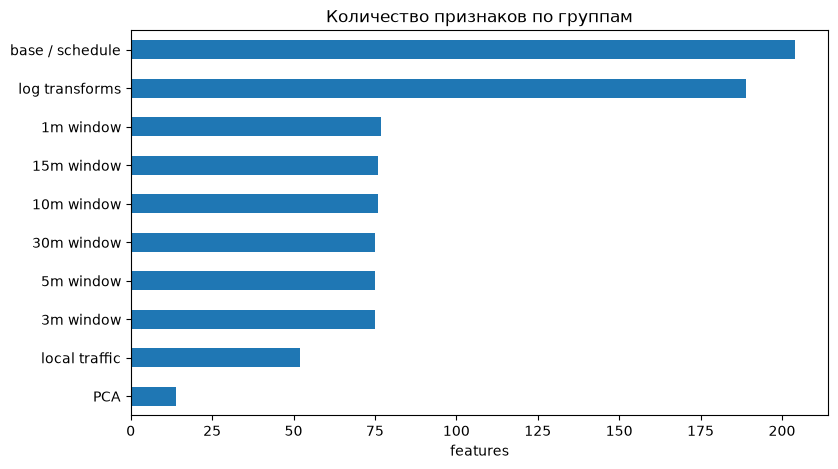

In [140]:
fe_families.sort_values().plot.barh(figsize=(9, 5))
plt.title('Количество признаков по группам')
plt.xlabel('features')
plt.show()


### Что дали log-преобразования


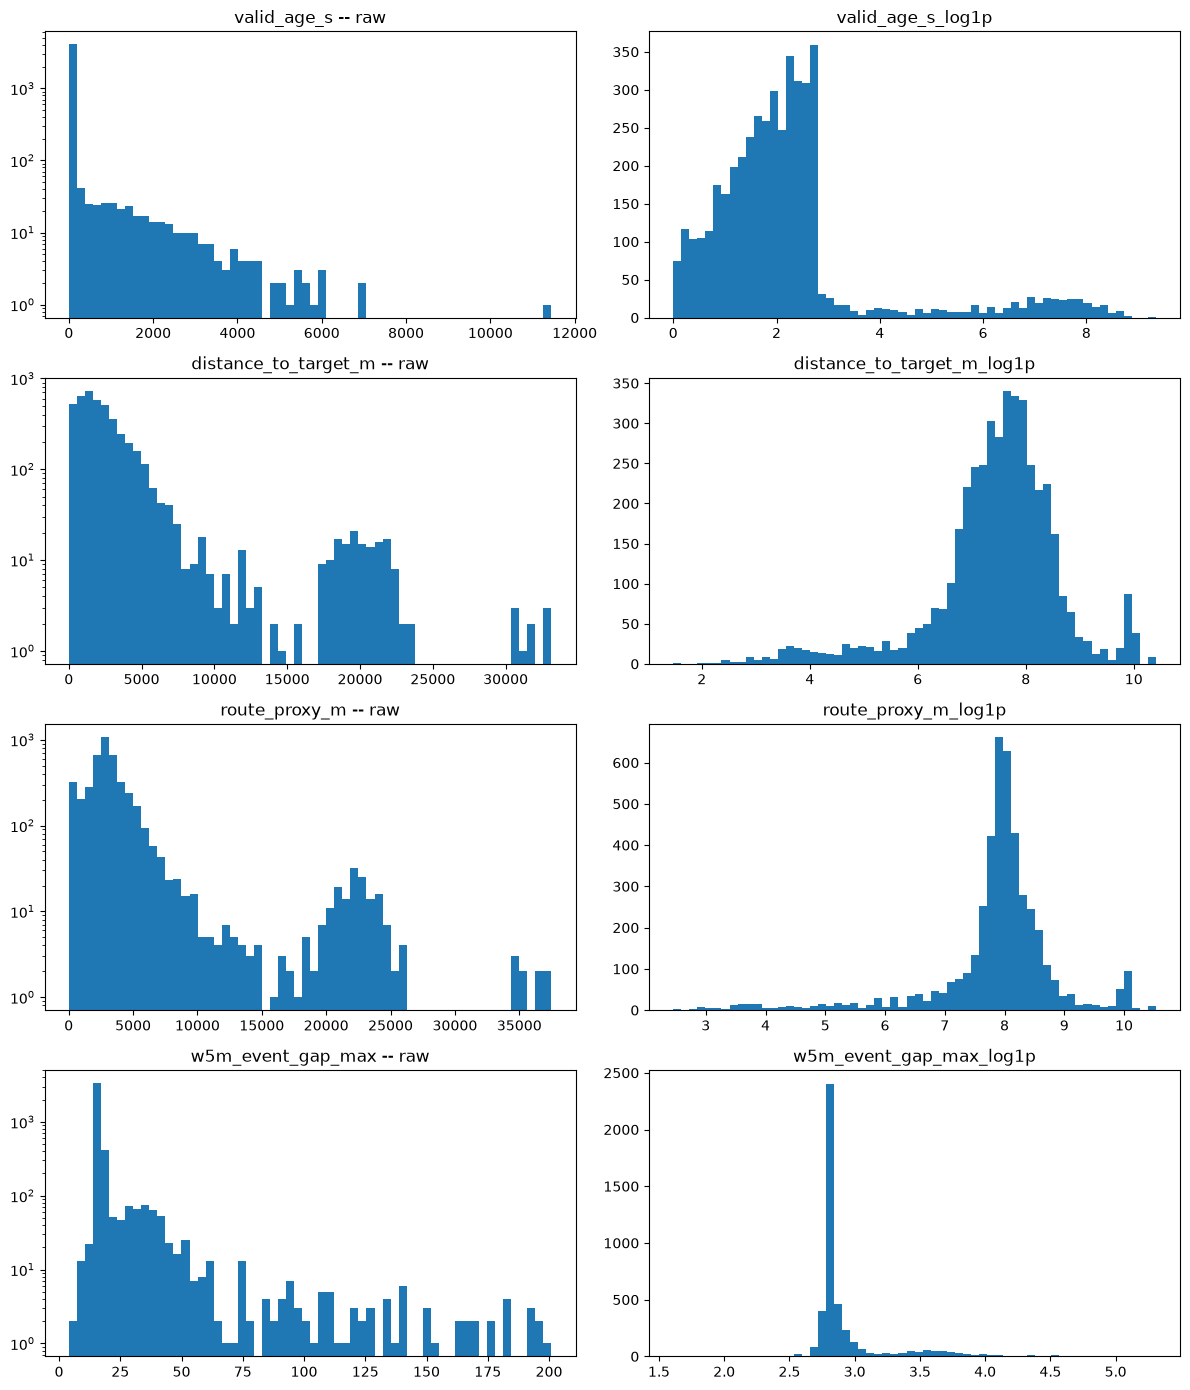

In [141]:
fe_transform_examples = []
for raw in ['valid_age_s', 'distance_to_target_m', 'route_proxy_m', 'w5m_event_gap_max']:
    suffix = '_log1p' if fe_transform_specs.get(raw) == 'log' else '_signed_log1p'
    transformed = raw + suffix
    if transformed in fe_train_features.columns:
        fe_transform_examples.append((raw, transformed))

fe_fig, fe_axes = plt.subplots(
    len(fe_transform_examples), 2,
    figsize=(12, 3.5 * len(fe_transform_examples))
)
fe_axes = np.atleast_2d(fe_axes)

for row, (raw, transformed) in enumerate(fe_transform_examples):
    fe_axes[row, 0].hist(fe_train_features[raw].dropna(), bins=60)
    fe_axes[row, 0].set_yscale('log')
    fe_axes[row, 0].set_title(raw + ' -- raw')

    fe_axes[row, 1].hist(fe_train_features[transformed].dropna(), bins=60)
    fe_axes[row, 1].set_title(transformed)

plt.tight_layout()


В raw-версии редкие большие значения растягивают шкалу. `log1p` сохраняет порядок наблюдений, но сильнее раскрывает основную массу. Raw и log оставляю одновременно -- это не замена, а дополнительное представление.


### Связь новых признаков с target


In [142]:
fe_corr_cols = [
    'cur_dev_s',
    'distance_to_target_m',
    'required_speed_kmh',
    'route_proxy_required_speed_kmh',
    'speed_margin_kmh',
    'w5m_speed_mean',
    'w5m_speed_slope',
    'w5m_slow_share',
    'w5m_target_progress_kmh',
    'w15m_target_progress_kmh',
    'valid_age_s',
    'scheduled_stops_to_target',
    'city_speed_mean',
    'local_speed_mean_1000m',
    'target_area_speed_mean_1000m',
    'target_delay_s'
]

fe_physical_corr = fe_train_features[fe_corr_cols].corr()
fe_physical_corr


,cur_dev_s,distance_to_target_m,required_speed_kmh,route_proxy_required_speed_kmh,speed_margin_kmh,w5m_speed_mean,w5m_speed_slope,w5m_slow_share,w5m_target_progress_kmh,w15m_target_progress_kmh,valid_age_s,scheduled_stops_to_target,city_speed_mean,local_speed_mean_1000m,target_area_speed_mean_1000m,target_delay_s
cur_dev_s,1.000,0.053,0.053,0.039,-0.062,-0.018,0.027,-0.005,-0.011,-0.019,-0.071,-0.056,-0.000,0.008,-0.038,0.511
distance_to_target_m,0.053,1.000,0.995,0.968,-0.380,0.546,0.056,-0.073,-0.081,-0.405,0.331,0.082,-0.009,0.644,0.143,0.024
required_speed_kmh,0.053,0.995,1.000,0.973,-0.398,0.528,0.058,-0.065,-0.079,-0.399,0.342,0.088,-0.009,0.635,0.142,0.027
route_proxy_required_speed_kmh,0.039,0.968,0.973,1.000,-0.328,0.543,0.064,-0.069,-0.086,-0.428,0.378,0.152,0.006,0.668,0.195,0.033
speed_margin_kmh,-0.062,-0.380,-0.398,-0.328,1.000,0.095,0.108,-0.212,0.067,0.171,-0.121,-0.045,0.058,-0.004,0.138,-0.105
w5m_speed_mean,-0.018,0.546,0.528,0.543,0.095,1.000,-0.027,-0.667,0.082,-0.192,-0.214,0.043,0.007,0.421,0.162,-0.050
w5m_speed_slope,0.027,0.056,0.058,0.064,0.108,-0.027,1.000,-0.001,-0.475,-0.121,-0.010,0.042,-0.000,0.040,0.106,-0.011
w5m_slow_share,-0.005,-0.073,-0.065,-0.069,-0.212,-0.667,-0.001,1.000,-0.106,-0.152,0.384,-0.236,-0.018,-0.126,-0.114,0.041
w5m_target_progress_kmh,-0.011,-0.081,-0.079,-0.086,0.067,0.082,-0.475,-0.106,1.000,0.320,0.102,0.026,0.001,0.112,0.061,-0.015
w15m_target_progress_kmh,-0.019,-0.405,-0.399,-0.428,0.171,-0.192,-0.121,-0.152,0.320,1.000,-0.012,0.077,0.016,-0.126,-0.031,-0.015


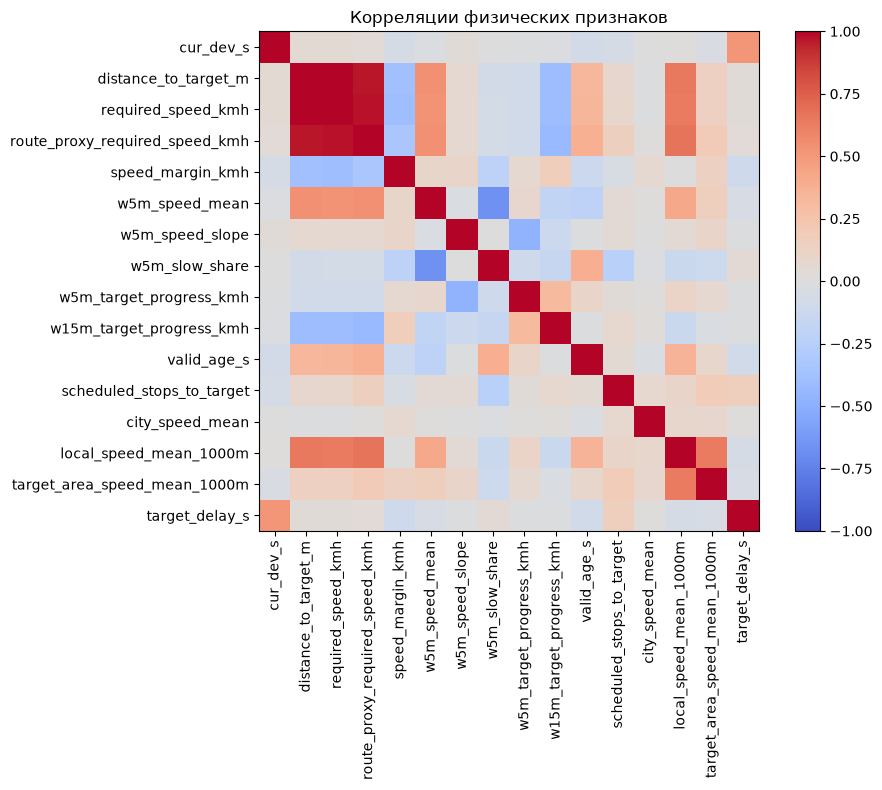

In [143]:
fe_fig, fe_ax = plt.subplots(figsize=(10, 8))
fe_corr_im = fe_ax.imshow(fe_physical_corr, vmin=-1, vmax=1, cmap='coolwarm')

fe_ax.set_xticks(range(len(fe_physical_corr.columns)))
fe_ax.set_xticklabels(fe_physical_corr.columns, rotation=90)
fe_ax.set_yticks(range(len(fe_physical_corr.index)))
fe_ax.set_yticklabels(fe_physical_corr.index)

plt.colorbar(fe_corr_im, ax=fe_ax)
plt.title('Корреляции физических признаков')
plt.tight_layout()


In [144]:
fe_corr_numeric = [
    col for col in fe_train_features[fe_feature_cols].select_dtypes(include=['number', 'bool']).columns
    if fe_train_features[col].nunique(dropna=True) > 1
]
fe_corr_numeric_frame = fe_train_features[fe_corr_numeric].astype(float)
fe_target = fe_train_features.target_delay_s.astype(float)

fe_pearson = fe_corr_numeric_frame.corrwith(fe_target).dropna()
fe_spearman = fe_corr_numeric_frame.rank().corrwith(fe_target.rank()).dropna()

fe_top_corr = pd.DataFrame({
    'pearson': fe_pearson,
    'spearman': fe_spearman
})
fe_top_corr['max_abs'] = fe_top_corr.abs().max(axis=1)

fe_top_corr.sort_values('max_abs', ascending=False).head(30)


,pearson,spearman,max_abs
cur_dev_per_min,0.516,0.480,0.516
cur_dev_s,0.511,0.479,0.511
cur_dev_x_w15_valid_share,0.501,0.479,0.501
cur_dev_x_horizon,0.500,0.476,0.500
cur_dev_sqrt,0.490,0.479,0.490
cur_dev_x_required_speed_signed_log1p,0.434,0.483,0.483
cur_dev_x_required_speed,0.457,0.483,0.483
cur_dev_x_distance_km_signed_log1p,0.449,0.481,0.481
cur_dev_x_distance_km,0.449,0.481,0.481
cur_dev_log,0.439,0.479,0.479


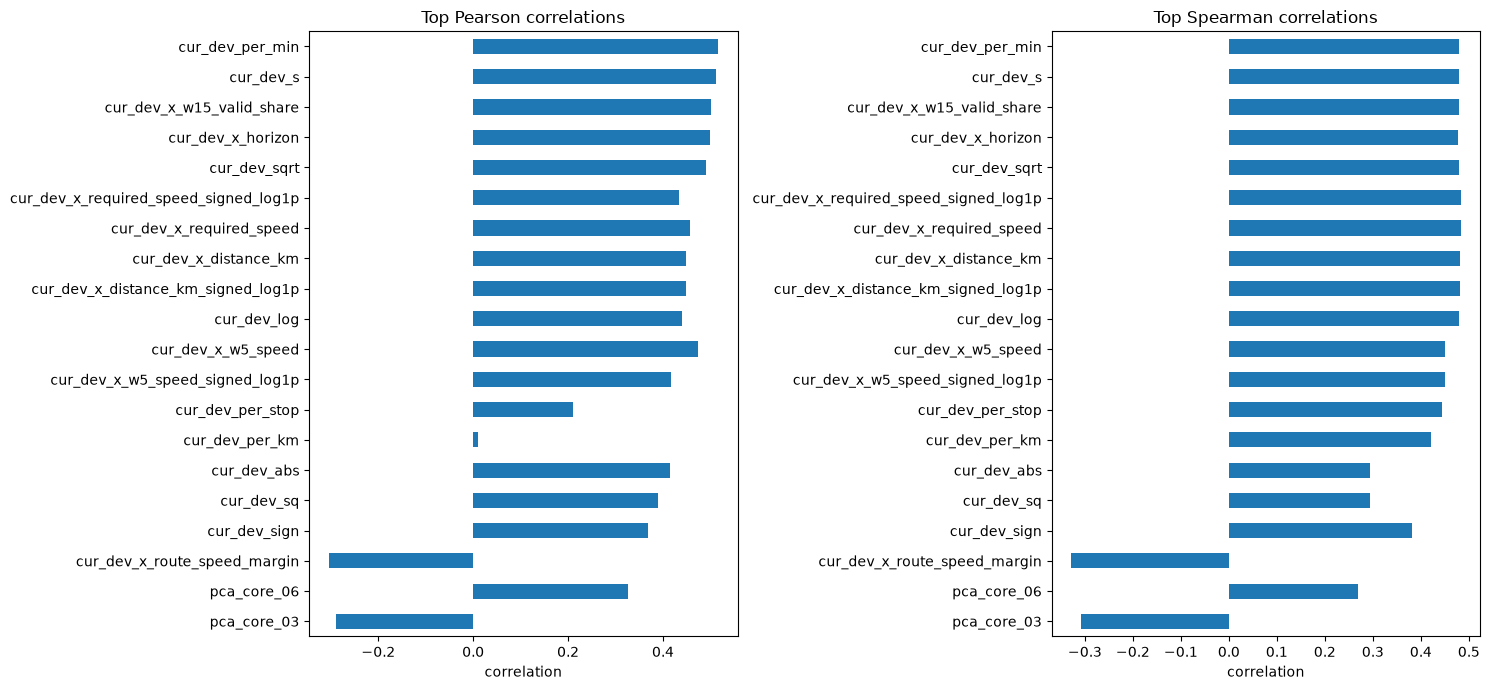

In [145]:
fe_top = fe_top_corr.sort_values('max_abs', ascending=False).head(20).sort_values('max_abs')

fe_fig, fe_axes = plt.subplots(1, 2, figsize=(15, 7))

fe_top.pearson.plot.barh(ax=fe_axes[0])
fe_axes[0].set_title('Top Pearson correlations')
fe_axes[0].set_xlabel('correlation')

fe_top.spearman.plot.barh(ax=fe_axes[1])
fe_axes[1].set_title('Top Spearman correlations')
fe_axes[1].set_xlabel('correlation')

plt.tight_layout()


Парная корреляция здесь только sanity check. Семейство `cur_dev_s` ожидаемо сильное, но новые физические признаки могут быть полезны через нелинейные взаимодействия даже при слабой одномерной корреляции.

### Несколько boxplot по классам target


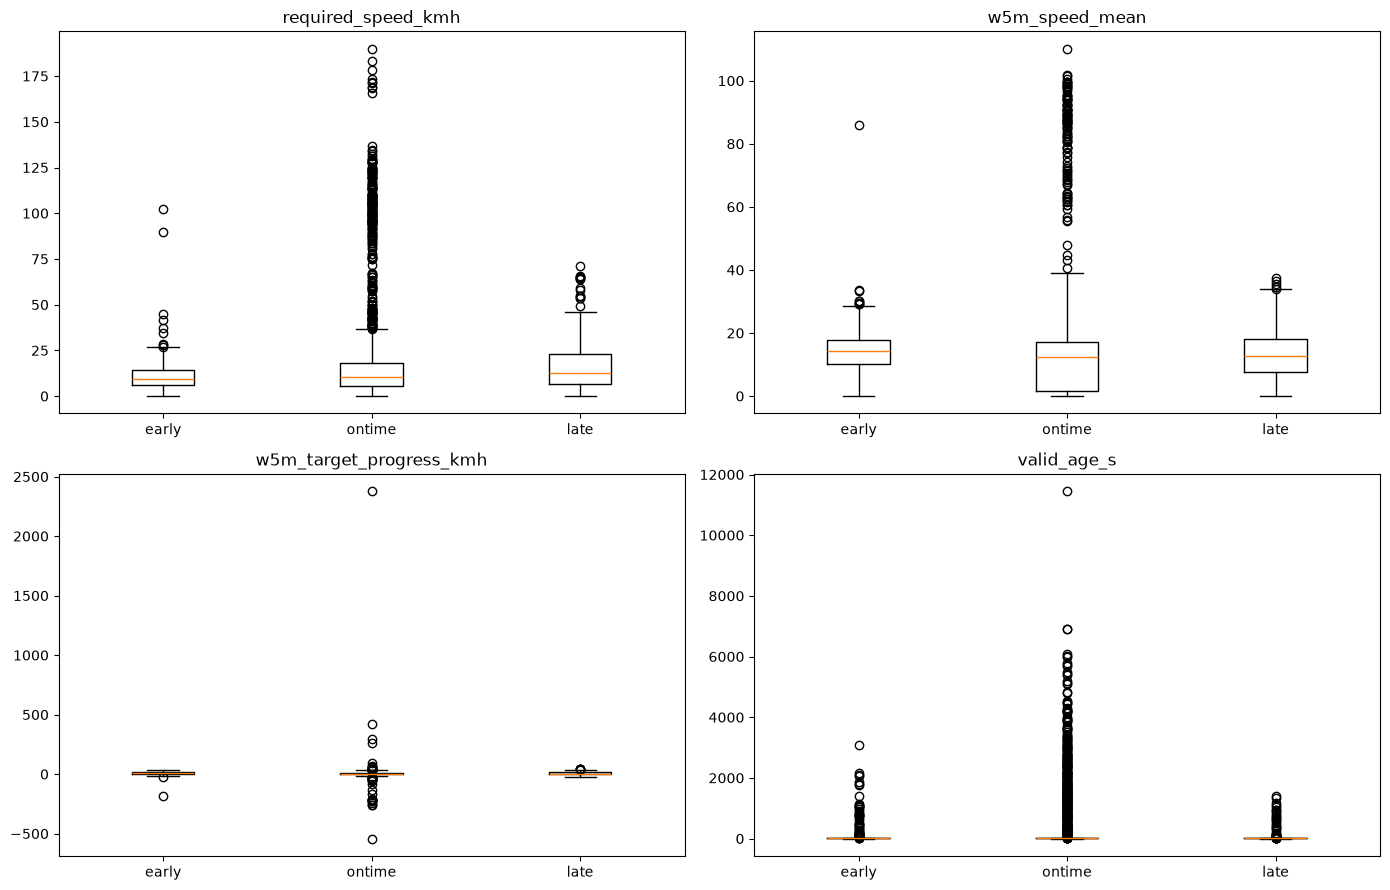

In [146]:
fe_box_cols = [
    'required_speed_kmh',
    'w5m_speed_mean',
    'w5m_target_progress_kmh',
    'valid_age_s'
]
fe_order = ['early', 'ontime', 'late']

fe_fig, fe_axes = plt.subplots(2, 2, figsize=(14, 9))

for fe_box_ax, col in zip(fe_axes.flat, fe_box_cols):
    fe_box_values = [
        fe_train_features.loc[
            fe_train_features.target_class == cls, col
        ].dropna()
        for cls in fe_order
    ]
    fe_box_ax.boxplot(fe_box_values, tick_labels=fe_order, showfliers=True)
    fe_box_ax.set_title(col)

plt.tight_layout()


Boxplot не показывает сильного одномерного разделения классов. Это подтверждает EDA: задача определяется комбинацией текущего delay, динамики движения, расписания и локального контекста, а не одним признаком.

## Что еще можно добавить позже

Если базовые модели покажут пользу пространственного контекста, следующий шаг -- H3/geohash агрегации и исторические статистики по сегментам/ячейкам с временной CV.

Еще один сильный кандидат -- модель residual относительно `cur_dev_s`: предсказывать, насколько задержка изменится за следующие 10--15 минут, а не сам target с нуля.

## 13. Сохранение


In [147]:
fe_features_dir = Path('../dataset/features')
fe_features_dir.mkdir(exist_ok=True)

fe_train_features.to_pickle(fe_features_dir / 'train_features.pkl')
fe_test_features.to_pickle(fe_features_dir / 'test_features.pkl')
fe_validate_features.to_pickle(fe_features_dir / 'validate_features.pkl')

pd.Series(fe_feature_cols).to_csv(
    fe_features_dir / 'feature_columns.csv',
    index=False,
    header=['feature']
)
pd.Series(fe_categorical_features).to_csv(
    fe_features_dir / 'categorical_features.csv',
    index=False,
    header=['feature']
)


На выходе:

- `../dataset/features/train_features.pkl`;
- `../dataset/features/test_features.pkl`;
- `../dataset/features/validate_features.pkl`;
- список всех признаков и отдельно categorical.

Следующий notebook может сразу читать эти таблицы. До обучения я бы **не делал ручной feature selection по train target**: сначала нужен честный real test и learning curves, затем уже ablation по семьям признаков.
